In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#e6edf3",
    "ytick.color": "#e6edf3",
    "grid.color": "#2f3542",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#e6edf3",
    "font.size": 12,
})
COLOR_MAP = {
    "LMS": "#58a6ff",        # bright blue
    "NLMS": "#2dd4bf",       # cyan
    "APA (P=1)": "#f472b6",  # magenta
    "APA (P=2)": "#facc15",  # yellow
    "SignError": "#a3e635",  # lime
    "SignData": "#fb7185",   # red-pink
    "SignSign": "#c084fc",   # purple
    "DualSign": "#e879f9",
    "Pow2Err": "#fb923c",
}

In [2]:
np.random.seed(0)

N = 300

h = np.array([0.5 + 0j, -0.3 + 0j], dtype=np.complex64)

# Input
x = np.random.randn(N).astype(np.float32)

# Desired signal (2-tap FIR)
x_del = np.concatenate(([0.0], x[:-1]))
d = 0.5 * x + (-0.3) * x_del

# Add noise
d = d + 0.01 * np.random.randn(N).astype(np.float32)

In [3]:
nlms_mu_n = 0.5

filters = {
    "LMS": adspfilter.LMS(mu=0.05, filter_order=1),
    "NLMS": adspfilter.NLMS(mu=nlms_mu_n, tau=1e-3, filter_order=1),
    "APA (P=1)": adspfilter.AffineProjection(mu=0.5, P=1, delta=1e-3, filter_order=1),
    "APA (P=2)": adspfilter.AffineProjection(mu=0.5, P=2, delta=1e-3, filter_order=1),
    "SignError": adspfilter.SignErrorLMS(mu=0.02, filter_order=1),
    "SignData": adspfilter.SignDataLMS(mu=0.02, filter_order=1),
    "SignSign": adspfilter.SignSignLMS(mu=0.02, filter_order=1),
    "TD-DCT": adspfilter.TransformDomain(mu=0.02, alpha=0.01, gamma=1e-8,
                                         matrix="dct", filter_order=1),
    "TD-DFT": adspfilter.TransformDomain(mu=0.02, alpha=0.01, gamma=1e-8,
                                         matrix="dft", filter_order=1),
}


In [4]:
results = {}

for name, filt in filters.items():
    y, e, w_hist = filt(x.astype(np.complex64),
                        d.astype(np.complex64),
                        train=True)
    results[name] = (y, e, w_hist)

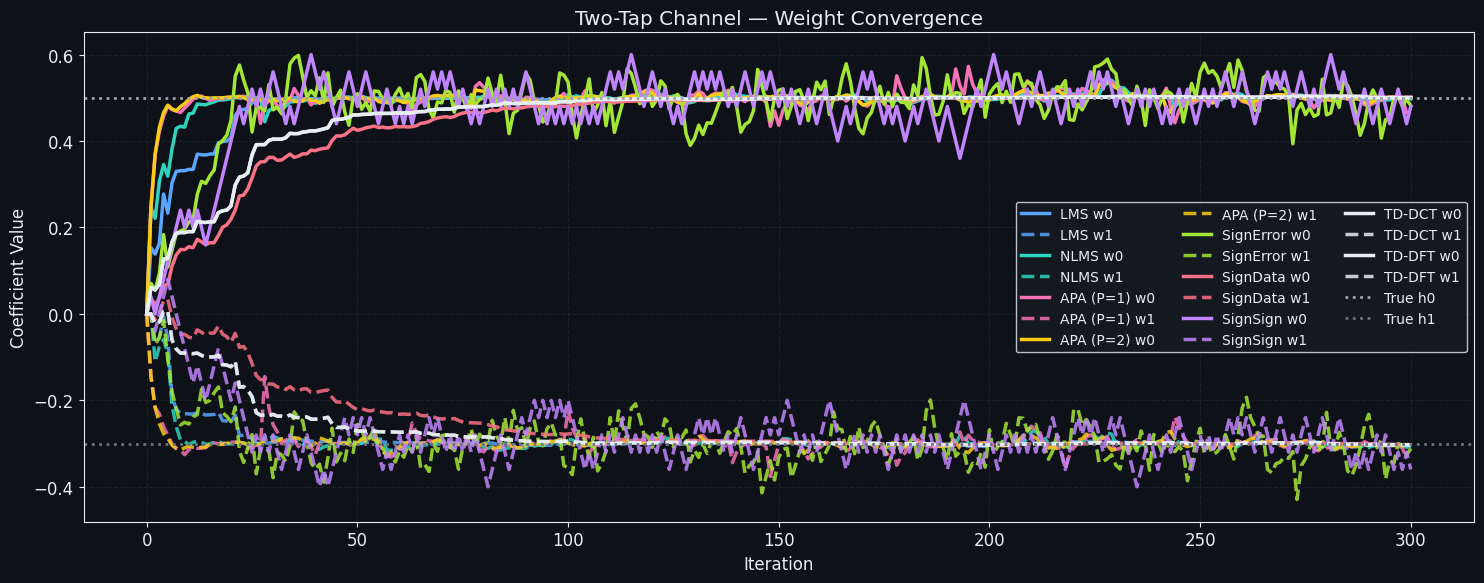

In [5]:
plt.figure(figsize=(15, 6))

for name, (y, e, w_hist) in results.items():
    color = COLOR_MAP.get(name, "#e6edf3")

    plt.plot(
        np.real(w_hist[:, 0]),
        color=color,
        linewidth=2.5,
        label=f"{name} w0",
    )

    plt.plot(
        np.real(w_hist[:, 1]),
        color=color,
        linewidth=2.5,
        linestyle="--",
        alpha=0.85,
        label=f"{name} w1",
    )

# True coefficients
plt.axhline(0.5, color="#9ca3af", linestyle=":", linewidth=2, label="True h0")
plt.axhline(-0.3, color="#6b7280", linestyle=":", linewidth=2, label="True h1")

plt.title("Two-Tap Channel — Weight Convergence")
plt.xlabel("Iteration")
plt.ylabel("Coefficient Value")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(ncol=3, fontsize=10)

plt.tight_layout()
plt.show()


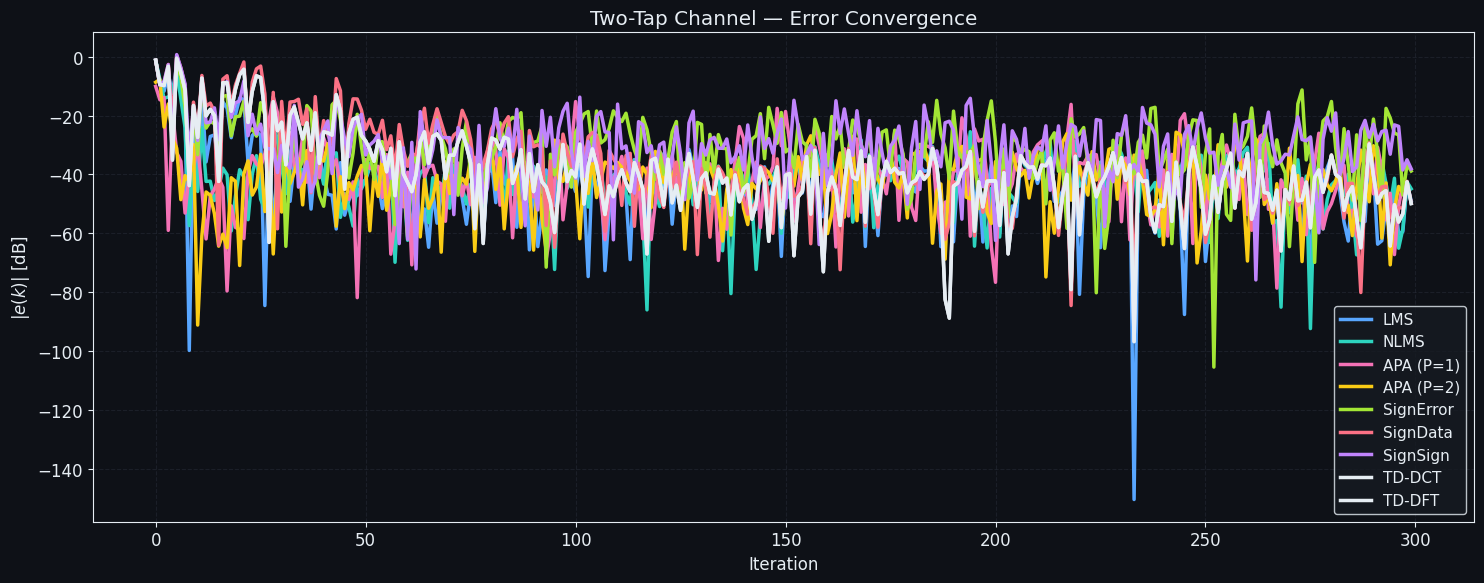

In [6]:
plt.figure(figsize=(15, 6))

for name, (y, e, w_hist) in results.items():
    color = COLOR_MAP.get(name, "#e6edf3")

    plt.plot(
        20 * np.log10(np.abs(e) + 1e-12),
        color=color,
        linewidth=2.5,
        label=name,
    )

plt.title("Two-Tap Channel — Error Convergence")
plt.xlabel("Iteration")
plt.ylabel(r"$|e(k)|$ [dB]")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()
